In [85]:
import pandas as pd
df=pd.read_excel('premiums_young.xlsx')
df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


In [86]:
df.isna().sum()

Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           2
Employment_Status        1
Income_Level             4
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
dtype: int64

In [87]:
df.Gender.unique(),df.Region.unique(),df.Marital_status.unique(),df.BMI_Category.unique(),df.Smoking_Status.unique(),df.Employment_Status.unique(),df.Income_Level.unique(),df['Medical History'].unique(),df.Insurance_Plan.unique()

(array(['Male', 'Female'], dtype=object),
 array(['Northeast', 'Northwest', 'Southeast', 'Southwest'], dtype=object),
 array(['Unmarried', 'Married'], dtype=object),
 array(['Overweight', 'Underweight', 'Normal', 'Obesity'], dtype=object),
 array(['Regular', 'No Smoking', 'Occasional', 'Smoking=0',
        'Does Not Smoke', 'Not Smoking', nan], dtype=object),
 array(['Self-Employed', 'Freelancer', 'Salaried', nan], dtype=object),
 array(['> 40L', '<10L', '10L - 25L', '25L - 40L', nan], dtype=object),
 array(['High blood pressure', 'No Disease',
        'Diabetes & High blood pressure', 'Diabetes & Heart disease',
        'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
        'High blood pressure & Heart disease'], dtype=object),
 array(['Silver', 'Bronze', 'Gold'], dtype=object))

In [88]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,20096.000000,20096.000000,20096.000000,20096.000000
mean,21.494029,0.718004,22.506519,8141.941033
std,2.294050,0.940767,23.418644,2749.609551
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.000000
50%,21.500000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [89]:
df.shape

(20096, 13)

In [90]:
df.columns=df.columns.str.replace(' ','_').str.lower()
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712


# Handing na Values

In [91]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [92]:
df.dropna(inplace=True) # size of dataset is very high and the na values are too low so we can drop na

In [93]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [94]:
print('Before: ',df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('After: ',df.duplicated().sum())

Before:  0
After:  0


In [95]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267
std,2.294052,0.940713,23.420493,2749.906347
min,18.000000,-3.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [96]:
df[df.number_of_dependants<0]['number_of_dependants']

150     -3
871     -3
906     -3
2462    -3
3059    -3
3120    -1
3780    -3
5593    -1
7585    -3
9765    -1
10029   -1
10109   -1
13256   -3
14764   -3
15224   -1
15246   -3
15499   -3
15671   -3
17503   -1
18145   -1
18553   -1
19296   -1
Name: number_of_dependants, dtype: int64

In [97]:
df['number_of_dependants'].abs().loc[[402,2245,2323,2986,2756,5846]]

402     0
2245    0
2323    1
2986    2
2756    0
5846    0
Name: number_of_dependants, dtype: int64

In [98]:
df['number_of_dependants']=df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


In [99]:
numeric_cols=df.select_dtypes(['float64','int64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

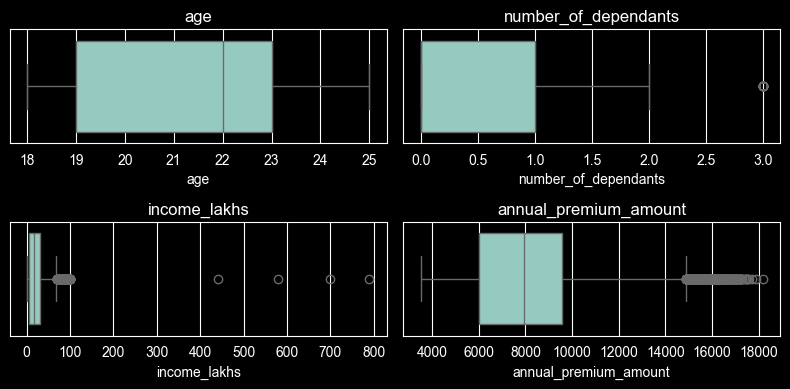

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [101]:
def get_iqr_bounds(col):
    q1,q3=col.quantile([0.25,0.75])
    iqr=q3-q1
    return (q1-1.5*iqr,q3+iqr*1.5)

In [102]:
df = df[df['age'] <= 100]

<Axes: xlabel='age'>

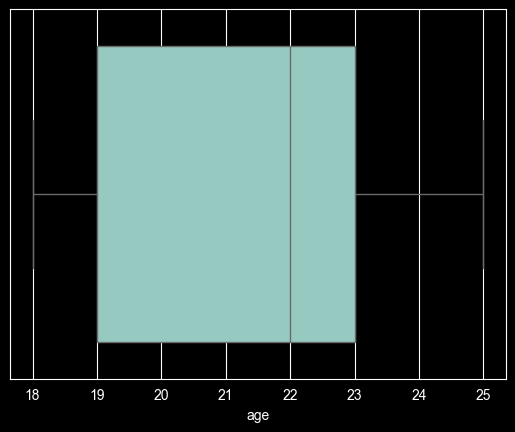

In [103]:
sns.boxplot(x=df['age'])

In [104]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.722598,22.510851,8142.096267
std,2.294052,0.937200,23.420493,2749.906347
min,18.000000,0.000000,1.000000,3501.000000
25%,19.000000,0.000000,6.000000,6022.250000
50%,22.000000,0.000000,16.000000,7939.000000
75%,23.000000,1.000000,31.000000,9561.000000
max,25.000000,3.000000,790.000000,18186.000000


<Axes: xlabel='income_lakhs', ylabel='Count'>

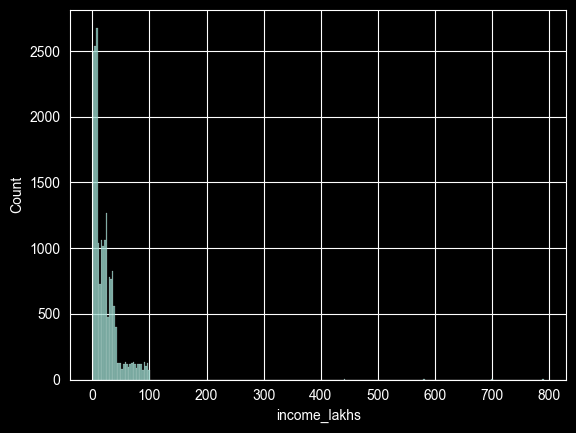

In [105]:
sns.histplot(df['income_lakhs'])

In [106]:
upper_income=get_iqr_bounds(df['income_lakhs'])[1] # the value we get is not that extreme so we try other things
quantile_threshold=df['income_lakhs'].quantile(0.999)
print(quantile_threshold)
df[df['income_lakhs']>quantile_threshold]['age'].count()

100.0


np.int64(4)

In [107]:
import numpy as np
df=df[df['income_lakhs']<=  quantile_threshold] # dropping the income greater than 100 because only 10 outliers

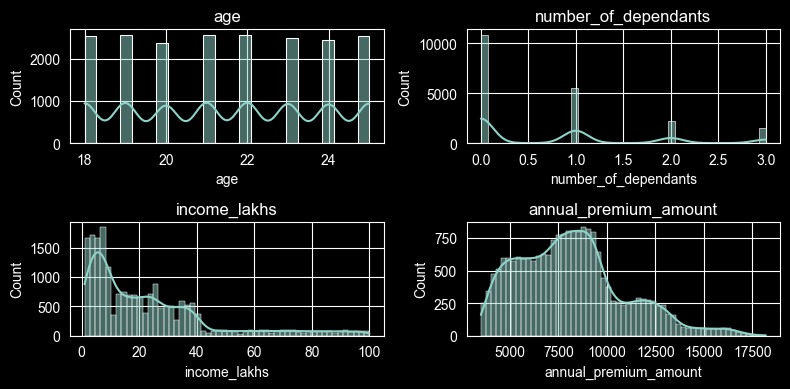

In [108]:
plt.figure(figsize=(8,4))
for i, col in enumerate(numeric_cols):
    plt.subplot((len(numeric_cols)+1)//2, 2, i+1)   # rows, columns, index
    sns.histplot(x=df[col],kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

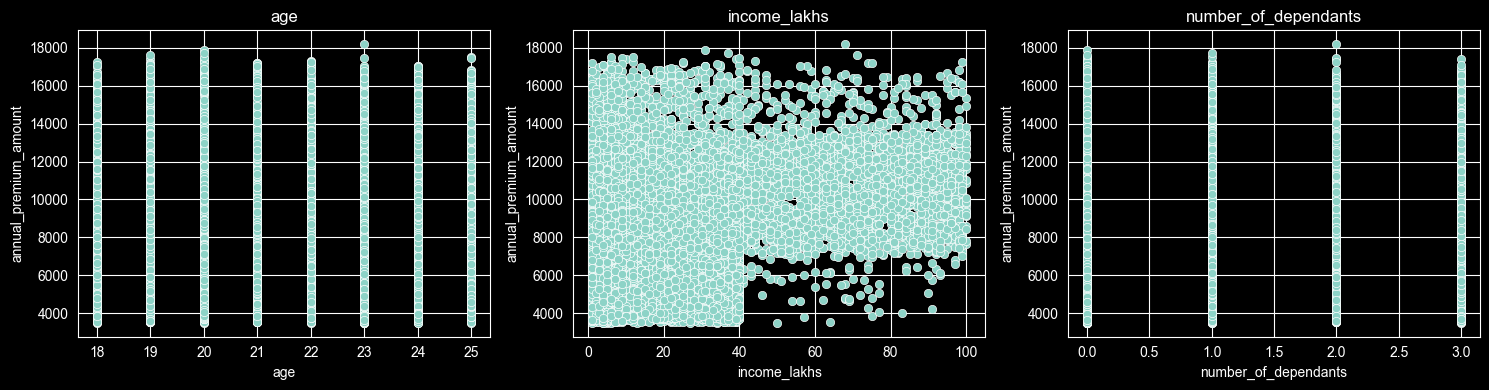

In [109]:
numeric_features = ['age','income_lakhs','number_of_dependants']
fig, axes = plt.subplots(1, len(numeric_features), figsize=(15,4))
for i, col in enumerate(numeric_features):
    sns.scatterplot(data=df, x=col, y='annual_premium_amount', ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [110]:
categorical_col=[ 'gender', 'region', 'marital_status','bmi_category', 'smoking_status', 'employment_status',  'medical_history', 'insurance_plan',]
for col in categorical_col:
    print(df[col].unique())

['Male' 'Female']
['Northeast' 'Northwest' 'Southeast' 'Southwest']
['Unmarried' 'Married']
['Overweight' 'Underweight' 'Normal' 'Obesity']
['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']
['Self-Employed' 'Freelancer' 'Salaried']
['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']
['Silver' 'Bronze' 'Gold']


In [111]:
df['smoking_status'].isna().sum()

np.int64(0)

In [112]:
df['smoking_status']=df['smoking_status'].replace({'Smoking=0':'No Smoking' ,'Does Not Smoke':'No Smoking','Not Smoking':'No Smoking'})

In [113]:
df['smoking_status'].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

In [114]:
df['smoking_status'].value_counts()

smoking_status
No Smoking    13860
Regular        4491
Occasional     1735
Name: count, dtype: int64

In [115]:
df['gender'].value_counts(normalize=True),df['gender'].isna().sum()

(gender
 Male      0.550383
 Female    0.449617
 Name: proportion, dtype: float64,
 np.int64(0))

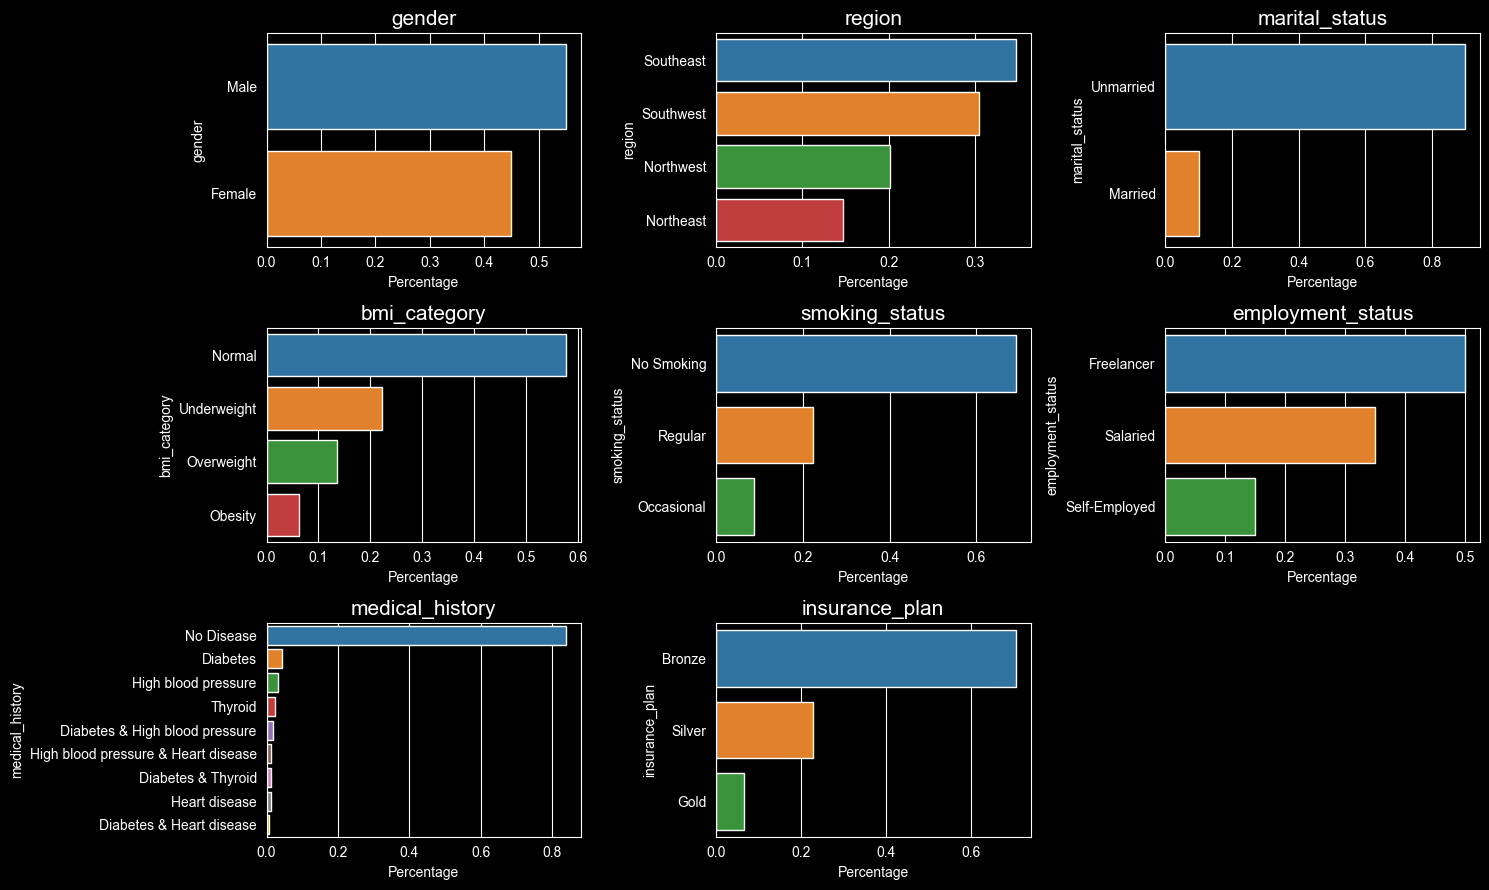

In [116]:
cols = categorical_col
n = len(cols)
rows = (n + 2) // 3   # calculate rows needed
fig, axes = plt.subplots(rows, 3, figsize=(15, 3*rows))
axes = axes.flatten()
for i, col in enumerate(cols):
    pct_count = df[col].value_counts(normalize=True)
    sns.barplot(x=pct_count.values,y=pct_count.index, ax=axes[i],hue=pct_count.index,palette='tab10')
    axes[i].set_title(col,fontsize=15)
    axes[i].set_xlabel("Percentage")
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

In [117]:
crosstab=pd.crosstab(df['income_level'],df['insurance_plan'])
crosstab

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,4508,326,828
25L - 40L,3382,209,608
<10L,6172,404,1145
> 40L,115,366,2023


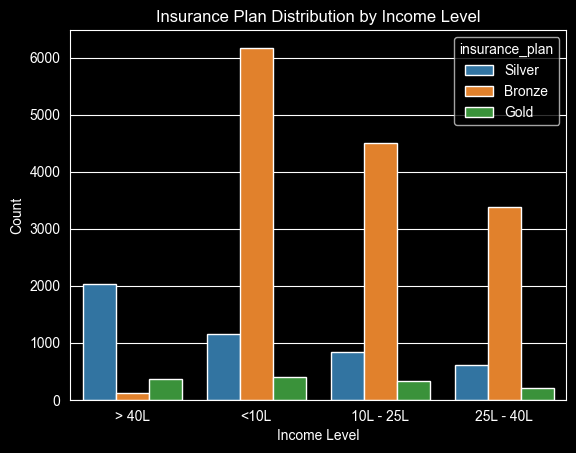

In [118]:
sns.countplot(data=df, x='income_level', hue='insurance_plan',palette='tab10')
plt.xlabel("Income Level")
plt.ylabel("Count")
plt.title("Insurance Plan Distribution by Income Level")
plt.show()

<Axes: xlabel='insurance_plan', ylabel='income_level'>

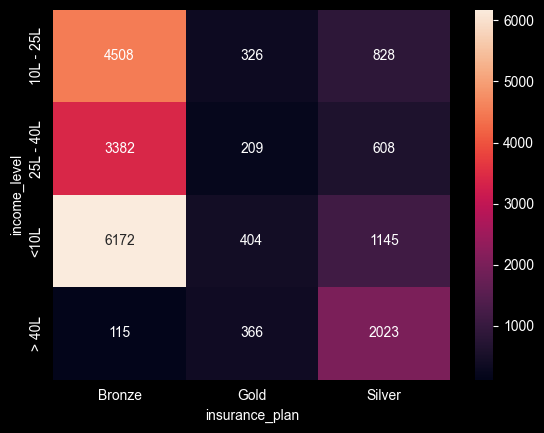

In [119]:
sns.heatmap(crosstab,annot=True,fmt="d")

In [120]:
df['medical_history'].unique()

array(['High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Diabetes & Heart disease',
       'Diabetes', 'Diabetes & Thyroid', 'Heart disease', 'Thyroid',
       'High blood pressure & Heart disease'], dtype=object)

In [121]:
df[['disease1','disease2']]=df['medical_history'].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
4380,20,Male,Southeast,Unmarried,0,Obesity,Regular,Salaried,> 40L,92,No Disease,Gold,12118,no disease,None
1643,24,Female,Southwest,Unmarried,1,Normal,No Smoking,Self-Employed,10L - 25L,16,No Disease,Bronze,8132,no disease,None
5329,18,Male,Southwest,Unmarried,1,Underweight,Regular,Salaried,> 40L,90,No Disease,Silver,11507,no disease,None
8137,20,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,> 40L,94,No Disease,Silver,10164,no disease,None
1941,20,Male,Northeast,Unmarried,0,Normal,Occasional,Freelancer,25L - 40L,36,No Disease,Bronze,5429,no disease,None


In [122]:
df['disease1'].fillna('none',inplace=True)
df['disease2'].fillna('none',inplace=True)

In [123]:
risk_score={
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'thyroid':5,
    'no disease':0,
    'none':0
}

In [124]:
df['total_risk_score']=df['disease1'].map(risk_score)+df['disease2'].map(risk_score)

In [125]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score
12043,19,Male,Southwest,Unmarried,0,Overweight,No Smoking,Salaried,<10L,2,No Disease,Bronze,9052,no disease,none,0
1751,21,Male,Southeast,Unmarried,1,Normal,No Smoking,Salaried,<10L,1,No Disease,Bronze,6185,no disease,none,0
4073,21,Female,Southeast,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,4,No Disease,Bronze,5428,no disease,none,0
2220,23,Female,Northwest,Married,2,Normal,No Smoking,Salaried,<10L,3,High blood pressure,Bronze,8624,high blood pressure,none,6
14920,18,Female,Southeast,Unmarried,0,Normal,No Smoking,Salaried,10L - 25L,17,No Disease,Bronze,5805,no disease,none,0


In [126]:
min_score=df['total_risk_score'].min()
max_score=df['total_risk_score'].max()
df['normalized_score']=((df['total_risk_score']-min_score)/(max_score-min_score))

In [127]:
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_score
8292,18,Male,Northeast,Unmarried,0,Underweight,Regular,Salaried,25L - 40L,25,No Disease,Bronze,5275,no disease,none,0,0.0
12536,22,Male,Southeast,Unmarried,0,Normal,No Smoking,Salaried,<10L,3,No Disease,Bronze,3909,no disease,none,0,0.0
5138,23,Male,Northwest,Unmarried,2,Normal,Regular,Salaried,<10L,1,No Disease,Bronze,9608,no disease,none,0,0.0
12451,24,Male,Southeast,Married,3,Underweight,Regular,Self-Employed,10L - 25L,13,No Disease,Bronze,8952,no disease,none,0,0.0
11318,22,Female,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,> 40L,41,No Disease,Silver,10059,no disease,none,0,0.0


In [128]:
df2=df.copy()

In [129]:
df2['insurance_plan']=df2['insurance_plan'].map({'Bronze':1,'Silver':2,'Gold':3})

In [130]:
df2.insurance_plan.unique()

array([2, 1, 3])

In [131]:
df2.income_level.unique()

array(['> 40L', '<10L', '10L - 25L', '25L - 40L'], dtype=object)

In [132]:
df2['income_level']=df2['income_level'].map({'<10L':1, '10L - 25L':2, '> 40L':3, '25L - 40L':4})

In [133]:
df2['income_level'].unique()

array([3, 1, 2, 4])

In [134]:
nominal_cols=['gender', 'region', 'marital_status','bmi_category','smoking_status', 'employment_status']
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)

In [135]:
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,3,99,High blood pressure,2,13365,high blood pressure,none,6,...,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,No Disease,2,11050,no disease,none,0,...,0,0,1,0,0,1,0,0,0,0
2,21,0,3,97,No Disease,2,11857,no disease,none,0,...,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,No Disease,1,5684,no disease,none,0,...,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,No Disease,1,5712,no disease,none,0,...,1,0,1,0,1,0,0,0,0,0


In [136]:
df4=df3.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)
df4.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,18,0,3,99,2,13365,0.428571,1,0,0,0,1,0,1,0,0,1,0,1
1,22,0,1,3,2,11050,0.000000,0,1,0,0,1,0,0,1,0,0,0,0
2,21,0,3,97,2,11857,0.000000,0,0,1,0,1,0,0,0,0,1,1,0
3,25,0,2,15,1,5684,0.000000,1,0,1,0,1,0,0,0,0,0,0,0
4,20,2,2,14,1,5712,0.000000,1,0,1,0,1,0,1,0,0,0,0,0


In [137]:
correlation=df4.corr()
correlation

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
age,1.000000,0.003096,-0.001661,-0.016671,-0.018195,-0.010815,0.003074,0.007791,0.002698,-0.003419,0.006922,0.000389,-0.001597,0.022006,-0.003068,-0.011040,-0.009827,-0.009493,0.001680
number_of_dependants,0.003096,1.000000,-0.010081,-0.014835,0.007802,0.005909,0.044009,-0.008213,0.014965,-0.000088,-0.011166,-0.722696,0.004090,0.002822,-0.000630,-0.015309,-0.001891,-0.013320,0.010281
income_level,-0.001661,-0.010081,1.000000,0.674861,0.123583,0.092784,0.001137,0.058815,-0.002084,0.000394,0.003493,0.007865,0.003539,0.015113,-0.013101,0.006205,0.013495,-0.148934,0.111289
income_lakhs,-0.016671,-0.014835,0.674861,1.000000,0.380968,0.290683,-0.006630,0.000951,-0.006349,-0.004859,0.015674,0.014021,0.014379,0.008312,-0.000598,0.006187,-0.010641,-0.084416,0.083316
insurance_plan,-0.018195,0.007802,0.123583,0.380968,1.000000,0.761004,0.001951,-0.016589,-0.006221,-0.007836,0.013644,-0.006561,0.002285,-0.006236,0.007766,-0.001517,-0.008755,-0.016911,0.026543
annual_premium_amount,-0.010815,0.005909,0.092784,0.290683,0.761004,1.000000,0.090702,0.000251,-0.017573,0.002388,0.008090,-0.008706,0.064828,0.036573,0.004972,0.008673,0.085407,-0.015318,0.024136
normalized_score,0.003074,0.044009,0.001137,-0.006630,0.001951,0.090702,1.000000,-0.000234,-0.000102,-0.008037,-0.004214,-0.056335,0.001278,0.000108,-0.010735,-0.008724,0.003557,-0.005101,-0.002150
gender_Male,0.007791,-0.008213,0.058815,0.000951,-0.016589,0.000251,-0.000234,1.000000,-0.002796,-0.000131,-0.002445,0.009276,-0.061257,0.043389,-0.060075,0.053469,0.202788,0.006978,-0.001052
region_Northwest,0.002698,0.014965,-0.002084,-0.006349,-0.006221,-0.017573,-0.000102,-0.002796,1.000000,-0.365912,-0.332236,-0.009604,-0.010099,0.003283,0.003720,-0.000543,-0.002375,0.010613,0.000254
region_Southeast,-0.003419,-0.000088,0.000394,-0.004859,-0.007836,0.002388,-0.008037,-0.000131,-0.365912,1.000000,-0.482398,0.000952,0.004409,0.010248,0.001118,-0.006319,-0.001805,-0.004268,0.000575


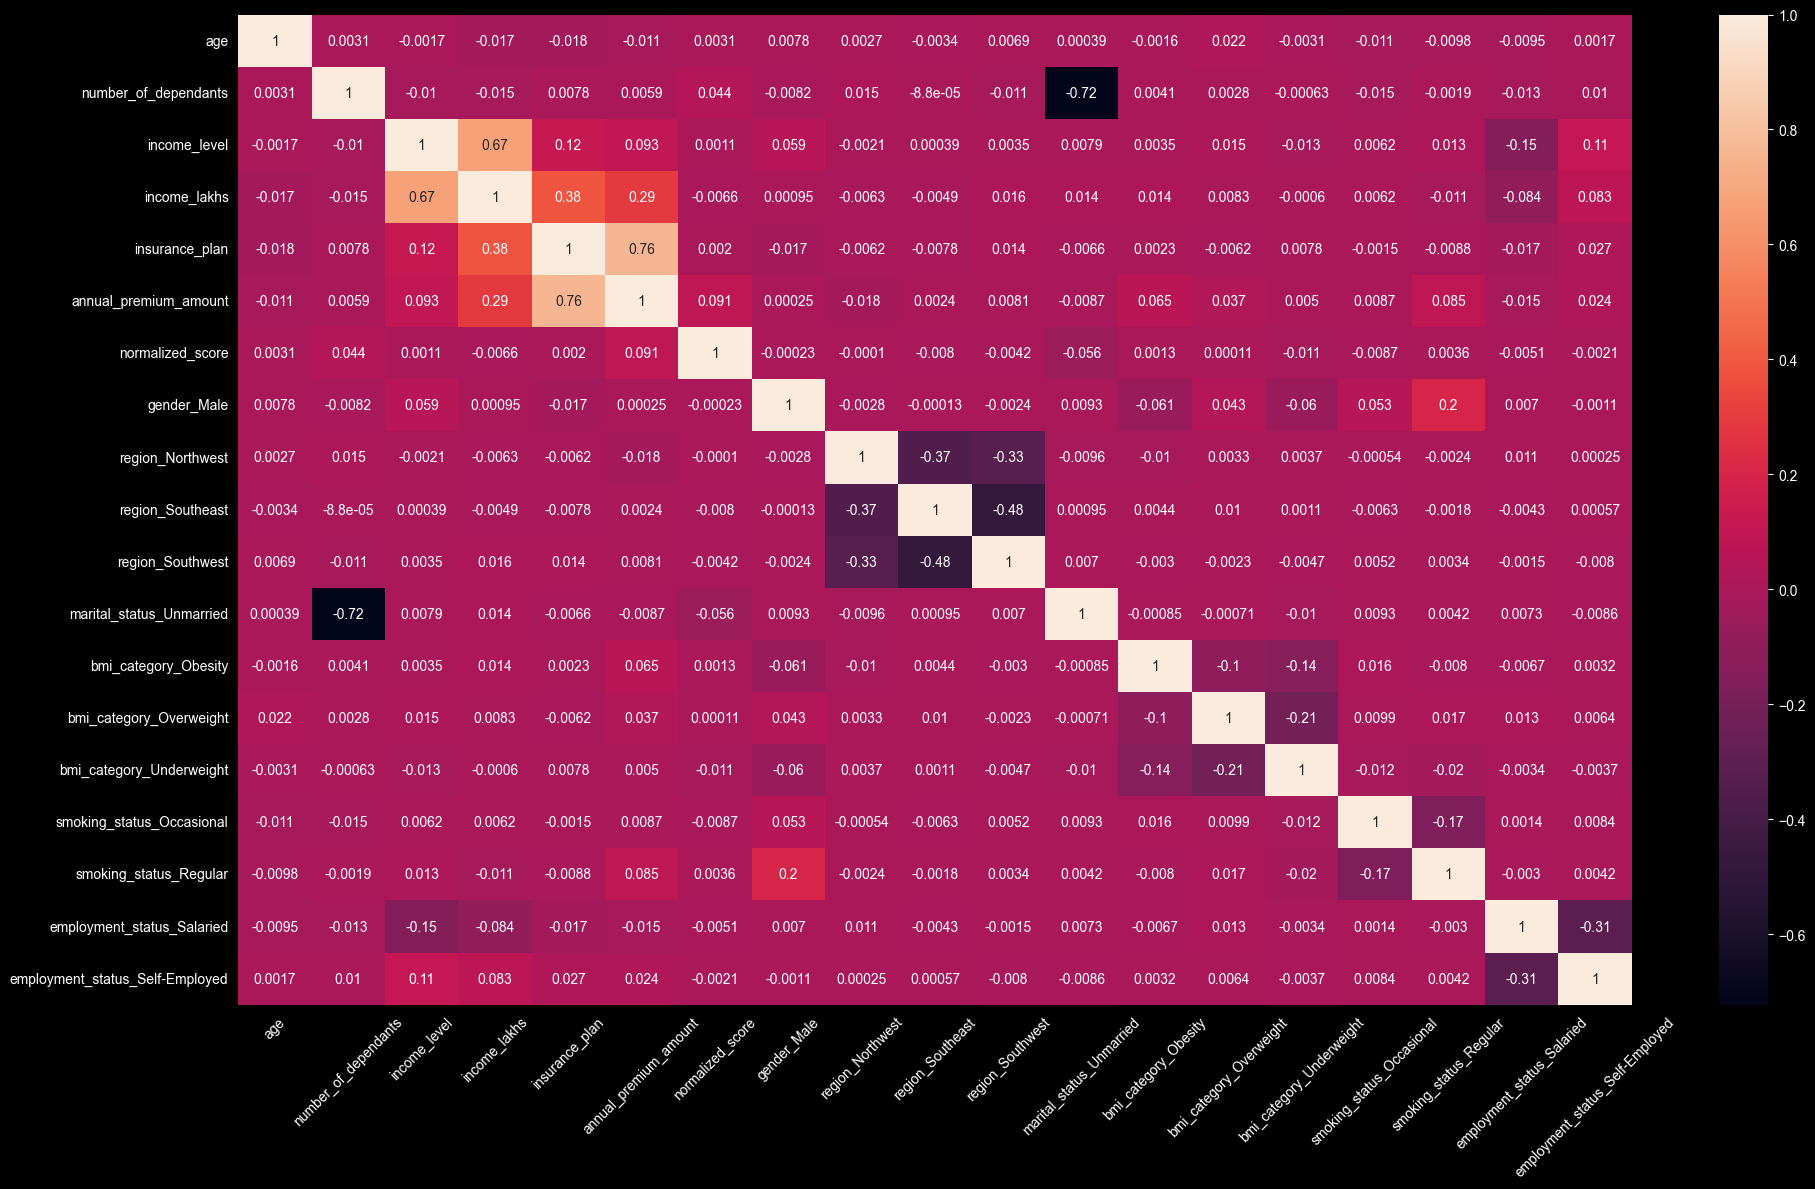

In [138]:
plt.figure(figsize=(20,12))
sns.heatmap(correlation,annot=True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [139]:
x=df4.drop(['annual_premium_amount'],axis=1)
y=df4['annual_premium_amount']
from sklearn.preprocessing import MinMaxScaler
cols_to_scale=['age', 'number_of_dependants', 'income_level', 'income_lakhs','insurance_plan']
scalar=MinMaxScaler()
x[cols_to_scale]=scalar.fit_transform(x[cols_to_scale])
x.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,0.499211,0.240914,0.386123,0.216064,0.179578,0.092076,0.550383,0.201284,0.346958,0.304590,0.899881,0.063527,0.136513,0.222493,0.086379,0.223589,0.350045,0.149955
std,0.327750,0.312413,0.383007,0.219516,0.300051,0.230016,0.497467,0.400970,0.476014,0.460245,0.300167,0.243914,0.343341,0.415931,0.280929,0.416660,0.476996,0.357036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.142857,0.000000,0.000000,0.050505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.571429,0.000000,0.333333,0.151515,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.714286,0.333333,0.666667,0.303030,0.500000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [140]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def vif(data):
    vif_df=pd.DataFrame()
    vif_df['features']=data.columns
    vif_df['vif']=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [141]:
vif(x)

,features,vif
0,age,3.144224
1,number_of_dependants,1.867394
2,income_level,3.915844
3,income_lakhs,4.343596
4,insurance_plan,1.647480
5,normalized_score,1.154461
6,gender_Male,2.317166
7,region_Northwest,2.148426
8,region_Southeast,2.971750
9,region_Southwest,2.731418


In [142]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [143]:
from sklearn.linear_model import LinearRegression
model_lr=LinearRegression()
model_lr.fit(x_train,y_train)
train_score=model_lr.score(x_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.6045609010380797, 0.5970440691689356)

In [144]:
x.columns,model_lr.coef_

(Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
        'insurance_plan', 'normalized_score', 'gender_Male', 'region_Northwest',
        'region_Southeast', 'region_Southwest', 'marital_status_Unmarried',
        'bmi_category_Obesity', 'bmi_category_Overweight',
        'bmi_category_Underweight', 'smoking_status_Occasional',
        'smoking_status_Regular', 'employment_status_Salaried',
        'employment_status_Self-Employed'],
       dtype='object'),
 array([   9.70654823,  -20.51879132,  -34.70758705,   71.10852612,
        6970.10072668, 1082.7989104 ,  -14.11624205, -106.76134456,
          -8.01330434,  -26.98087711,    8.23215601,  838.25920634,
         401.56414117,  162.90860833,  271.03149151,  647.02920771,
          -8.81801403,   13.93793887]))

In [145]:
feature_importance=pd.DataFrame(model_lr.coef_,index=x.columns,columns=['coefficient'])
feature_importance.sort_values(by='coefficient',ascending=True,inplace=True)
feature_importance

,coefficient
region_Northwest,-106.761345
income_level,-34.707587
region_Southwest,-26.980877
number_of_dependants,-20.518791
gender_Male,-14.116242
employment_status_Salaried,-8.818014
region_Southeast,-8.013304
marital_status_Unmarried,8.232156
age,9.706548
employment_status_Self-Employed,13.937939


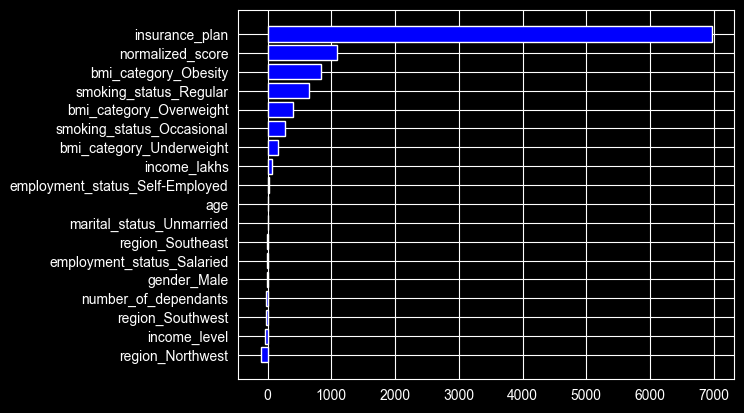

In [146]:
plt.barh(feature_importance.index,feature_importance['coefficient'],color='blue')
plt.show()

In [147]:
from sklearn.linear_model import Ridge
model_rg=Ridge()
model_rg.fit(x_train,y_train)
train_score=model_rg.score(x_train,y_train)
test_score=model_rg.score(x_test,y_test)
train_score,test_score

(0.6045605491119999, 0.5970488261566752)

In [148]:
from sklearn.tree import DecisionTreeRegressor
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train,y_train)
train_score=model_dt.score(x_train,y_train)
test_score=model_dt.score(x_test,y_test)
train_score,test_score

(0.9796914903883097, 0.16195028662996036)

In [149]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,root_mean_squared_error
model_xg=XGBRegressor()
model_xg.fit(x_train,y_train)
y_pred=model_xg.predict(x_test)
train_score=model_xg.score(x_train,y_train)
test_score=model_xg.score(x_test,y_test)
train_score,test_score,mean_squared_error(y_test,y_pred),root_mean_squared_error(y_test,y_pred)

(0.7173126935958862, 0.5519335269927979, 3404780.75, 1845.204833984375)

In [150]:
from sklearn.model_selection import GridSearchCV
params={
    "n_estimators":  [20,40,50],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth': [3,4,5]
}
grid=GridSearchCV(estimator=model_xg,param_grid=params,scoring='r2',cv=5,n_jobs=-1)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], 'n_estimators': [20, 40, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [151]:
grid.score(x_test,y_test)

0.5953594446182251

In [152]:
grid.best_score_

np.float64(0.6024558901786804)

In [172]:
best_model=model_lr

In [173]:
y_pred=best_model.predict(x_test)
residual=y_pred-y_test
residual_pct=residual*100/y_test
result_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residual,
    'diff_pct':residual_pct
})
result_df.head()

,actual,predicted,diff,diff_pct
10489,5452,6947.250882,1495.250882,27.425732
7989,9658,7566.945146,-2091.054854,-21.651013
3113,6031,8188.604996,2157.604996,35.775244
10605,12386,10862.350159,-1523.649841,-12.301387
4204,4245,7322.312513,3077.312513,72.492639


In [174]:
result_df[result_df['diff_pct']>10].sample(5)

,actual,predicted,diff,diff_pct
19177,7309,10162.947777,2853.947777,39.047035
15191,4470,7168.212386,2698.212386,60.362693
4987,6086,7131.742909,1045.742909,17.182762
12979,5006,6809.659902,1803.659902,36.029962
11826,6000,7143.104934,1143.104934,19.051749


<Axes: xlabel='diff_pct', ylabel='Count'>

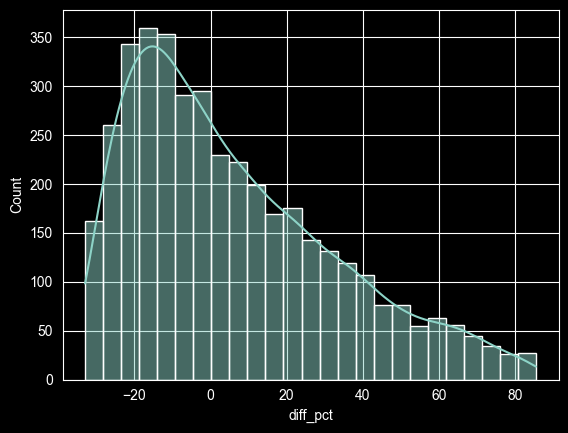

In [175]:
sns.histplot(result_df['diff_pct'],kde=True)

In [176]:
extreme_error_threshold=10
extreme_result_df=result_df[abs(result_df['diff_pct'])>extreme_error_threshold]
extreme_result_df.head()

,actual,predicted,diff,diff_pct
10489,5452,6947.250882,1495.250882,27.425732
7989,9658,7566.945146,-2091.054854,-21.651013
3113,6031,8188.604996,2157.604996,35.775244
10605,12386,10862.350159,-1523.649841,-12.301387
4204,4245,7322.312513,3077.312513,72.492639


In [177]:
extreme_error_pct=extreme_result_df.shape[0]*100/result_df.shape[0]
extreme_error_pct

72.64808362369338

In [178]:
result_df[np.abs(result_df['diff_pct'])>50].sort_values(by='diff_pct',ascending=False)

,actual,predicted,diff,diff_pct
12058,3503,6499.042626,2996.042626,85.527908
641,3522,6511.903604,2989.903604,84.892209
439,3611,6674.592060,3063.592060,84.840544
2975,3503,6457.213841,2954.213841,84.333824
13370,3617,6664.067158,3047.067158,84.242940
...,...,...,...,...
4671,4493,6749.454447,2256.454447,50.221555
813,4631,6955.324117,2324.324117,50.190545
16637,4326,6496.373690,2170.373690,50.170451
2360,4331,6501.548720,2170.548720,50.116572


In [179]:
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
10489,0.428571,1.0,0.000000,0.080808,0.0,0.428571,1,0,0,0,0,0,0,0,0,0,0,0
7989,0.714286,0.0,0.000000,0.030303,0.0,1.000000,1,0,0,1,1,0,0,0,0,0,0,0
3113,0.142857,0.0,1.000000,0.363636,0.0,1.000000,1,0,0,1,1,0,0,0,0,1,1,0
10605,0.428571,0.0,0.666667,0.515152,0.5,0.428571,1,0,1,0,1,0,1,0,0,0,0,0
4204,0.000000,0.0,0.333333,0.222222,0.0,0.000000,0,0,1,0,1,0,0,1,0,1,0,0


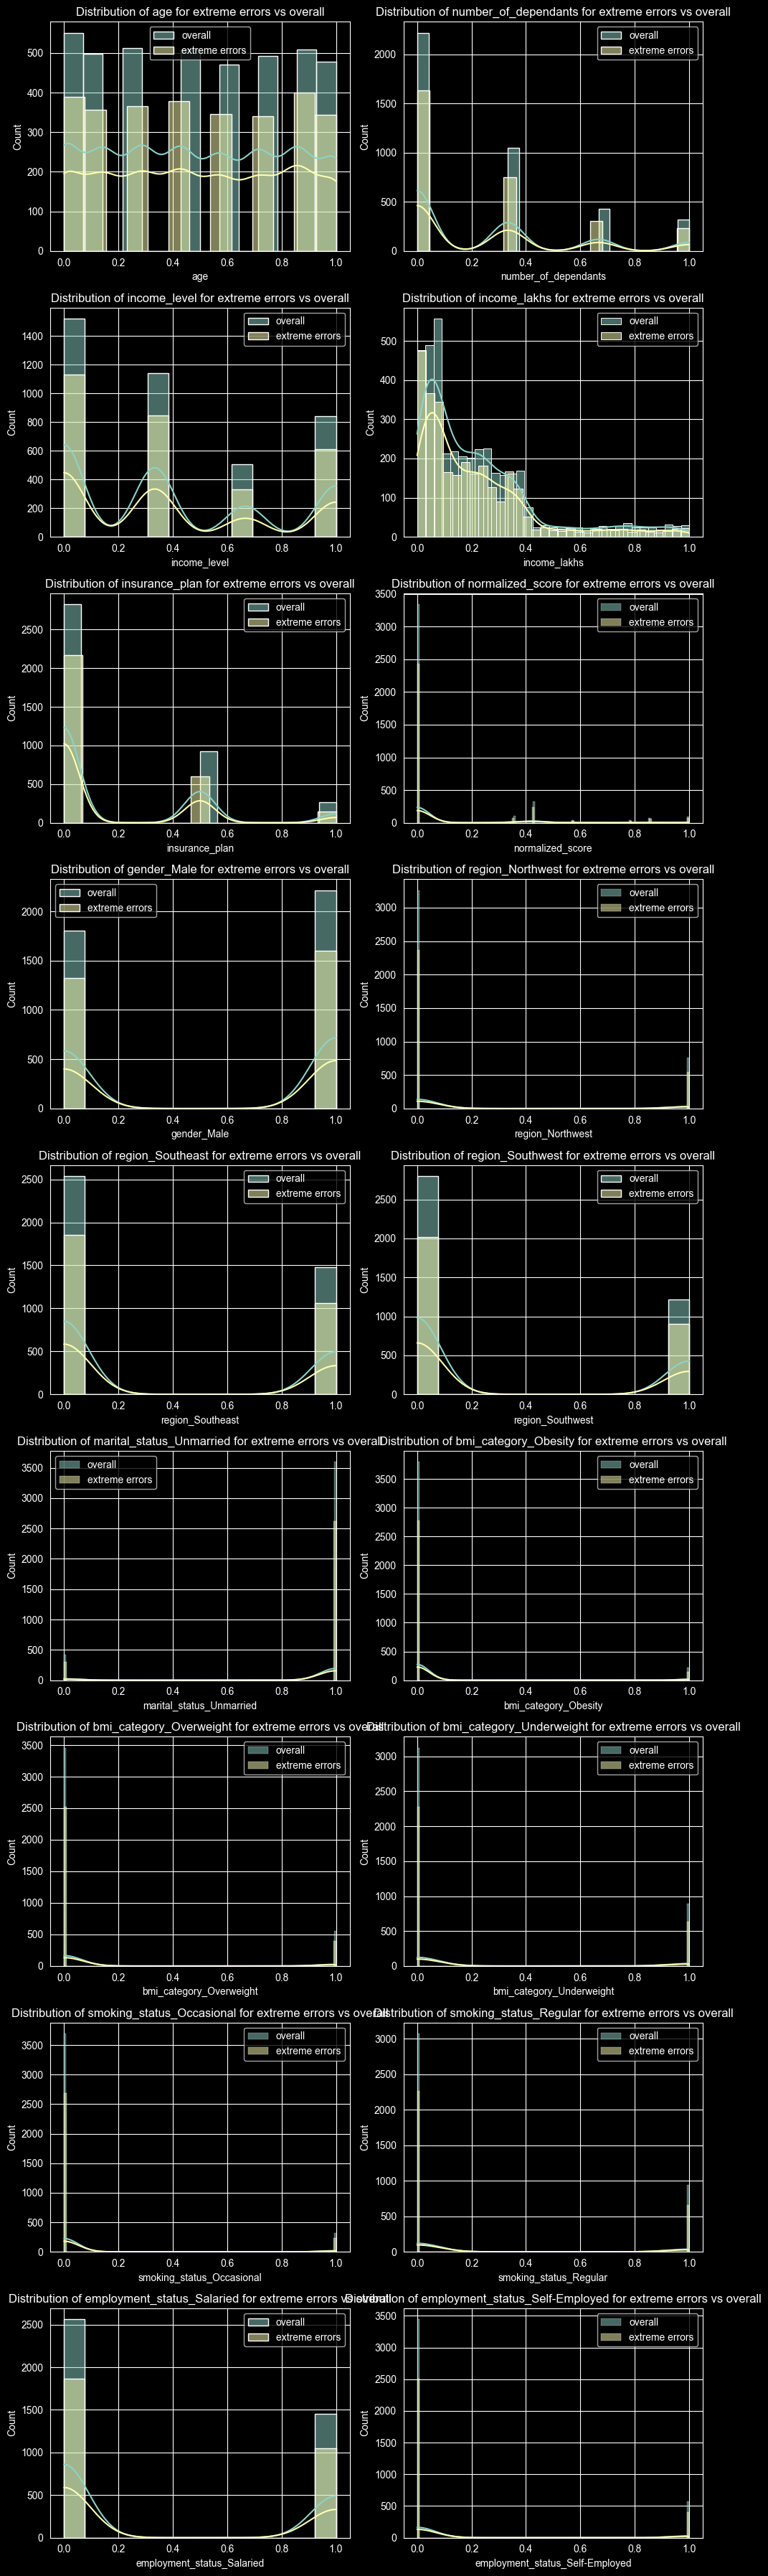

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
cols = 2
rows = int(np.ceil(len(x_test.columns) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(5*cols,4*rows))
axes = axes.flatten()
for i, feature in enumerate(x_test.columns):
    sns.histplot(x_test[feature], kde=True, label='overall', ax=axes[i])
    sns.histplot(extreme_error_df[feature], kde=True, label='extreme errors', ax=axes[i])
    axes[i].set_title(f'Distribution of {feature} for extreme errors vs overall')
    axes[i].legend()
plt.tight_layout()
plt.show()

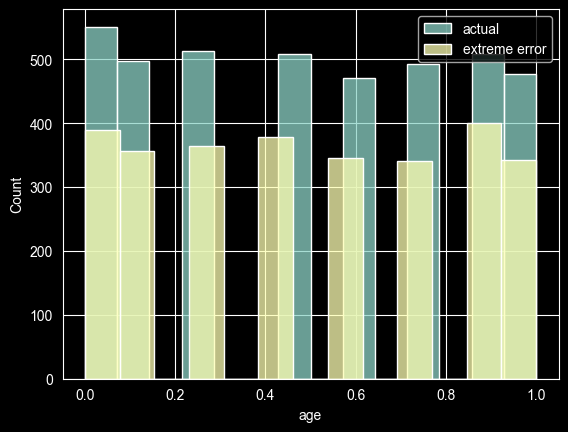

In [181]:
sns.histplot(x_test.age,label='actual')
sns.histplot(extreme_error_df.age,label='extreme error')
plt.legend()
plt.show()

In [182]:
df_reversed=pd.DataFrame(scalar.inverse_transform(extreme_error_df[cols_to_scale]),columns=cols_to_scale,index=extreme_error_df.index)
df_reversed.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
10489,21.0,3.0,1.0,9.0,1.0
7989,23.0,0.0,1.0,4.0,1.0
3113,19.0,0.0,4.0,37.0,1.0
10605,21.0,0.0,3.0,52.0,2.0
4204,18.0,0.0,2.0,23.0,1.0


<Axes: xlabel='age', ylabel='Count'>

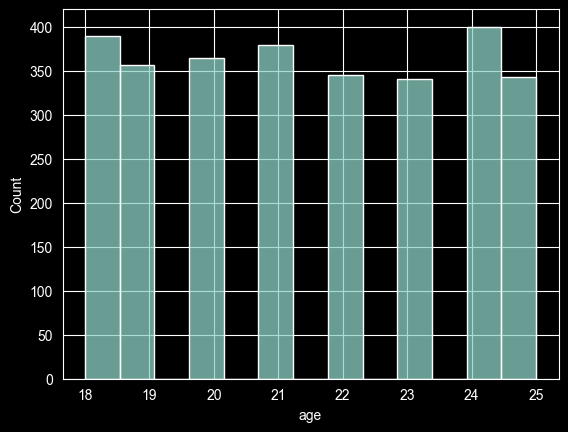

In [183]:
sns.histplot(df_reversed['age'])

In [184]:
df_reversed.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000
mean,21.463515,0.706064,2.144913,21.757109,1.305584
std,2.302059,0.946803,1.148904,21.084597,0.557649
min,18.000000,0.000000,1.000000,1.000000,1.000000
25%,19.000000,0.000000,1.000000,7.000000,1.000000
50%,21.000000,0.000000,2.000000,15.000000,1.000000
75%,24.000000,1.000000,3.000000,30.000000,2.000000
max,25.000000,3.000000,4.000000,100.000000,3.000000
